<a href="https://colab.research.google.com/github/davidlealo/tarea_1_sisrec_2026/blob/main/TAREA_1_test_2_SICREC_G26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 Sistemas de Recomendación
### Tarea 26


*   Marcelo Vargas
*   David Leal





In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 125.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version 

In [64]:
!pip install scikit-surprise --no-build-isolation --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 16.6 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2708560 sha256=a61fa77b6ac8b9b75dfb405f2e258878a7462473b447bb196b790e20161ca4b0
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


# Error con la versióin de numpy y solución

Estuve hablando con Gemini (https://gemini.google.com/share/0593148d28a8) y al bajar la versión de Numpy para usar Surprise hay problemas con algunos archivos, entonces estoy armando otra versión de este código solamente con los temas de Yahoo Music

In [1]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO

# Variable para URLs
BASE_URL = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/"

def get_url(file_name):
    return f"{BASE_URL}{file_name}"


df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                           names=['user_id', 'artist_id', 'rating'], header=None)
df_artists = pd.read_csv(get_url("ydata_artists.txt"), sep='\t',
                         names=['artist_id', 'artist_name', 'genre'], header=None)



def load_remote_npy(file_name):
    response = requests.get(get_url(file_name))
    return np.load(BytesIO(response.content), allow_pickle=True)


print("¡Datos cargados exitosamente de Música!")

¡Datos cargados exitosamente de Música!


✅ Librerías cargadas

1. ANÁLISIS DE DATOS - Cuadro 1
Cuadro 1 (raw) - copia esta tabla al informe:


,Training (raw),Validation (raw)
Number of Users,2549.000,2548.000
Number of Items,2631.000,2631.000
Total Ratings,531878.000,151630.000
Avg Ratings per User,208.660,59.510
Avg Ratings per Item,202.160,57.630
Avg Rating,18.550,18.600
Rating Std,30.510,30.570
Max Ratings per User,392.000,112.000
Max Ratings per Item,382.000,121.000
Density (%),7.931,2.262



Ratings 255 encontrados:
   Train: 0
   Val:   0
→ Quedan 531,878 ratings en train
→ Quedan 151,630 ratings en val

Cuadro 1 FINAL (para tu informe):


,Training,Validation
Number of Users,2549.000,2548.000
Number of Items,2631.000,2631.000
Total Ratings,531878.000,151630.000
Avg Ratings per User,208.660,59.510
Avg Ratings per Item,202.160,57.630
Avg Rating,18.550,18.600
Rating Std,30.510,30.570
Max Ratings per User,392.000,112.000
Max Ratings per Item,382.000,121.000
Density (%),7.931,2.262


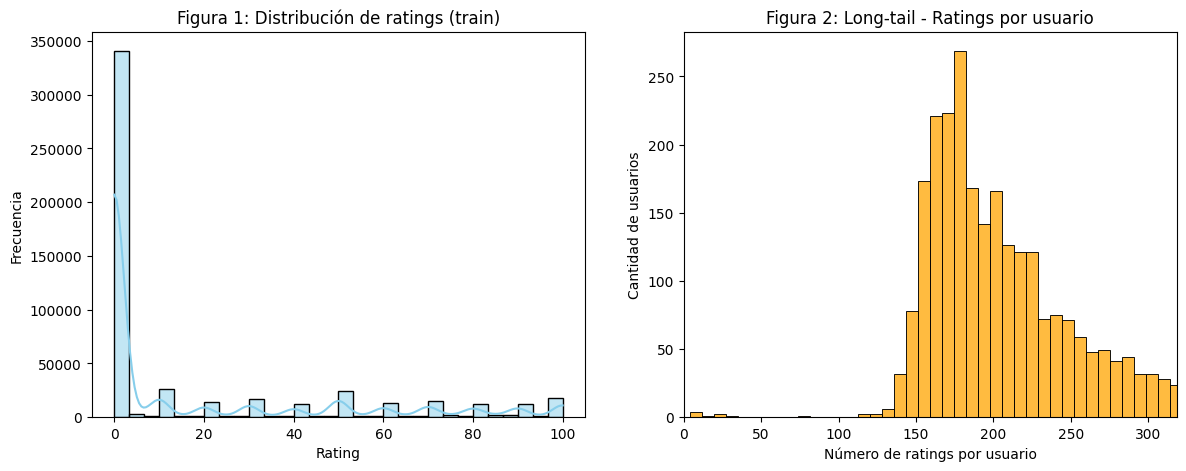

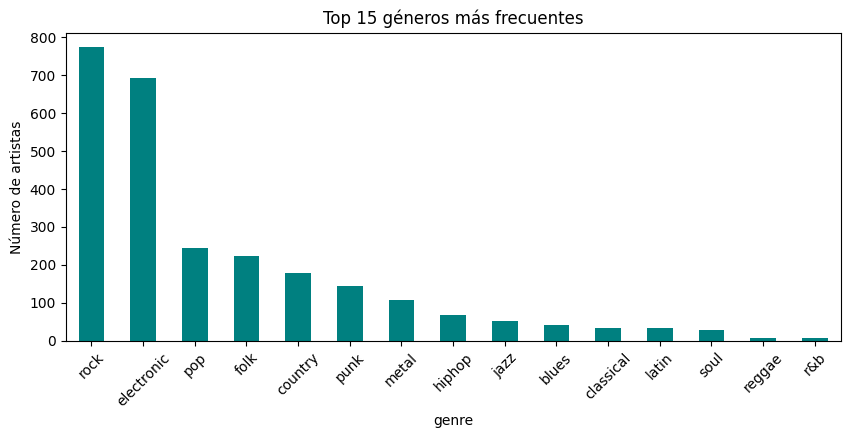


3. PREDICCIÓN DE RATINGS (UserKNN, ItemKNN, FunkSVD, SVD++)

🔹 Entrenando UserKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.
✅ UserKNN → RMSE: 27.5856 | MAE: 21.2160

🔹 Entrenando ItemKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.
✅ ItemKNN → RMSE: 21.7860 | MAE: 12.5651

🔹 Entrenando FunkSVD...
✅ FunkSVD → RMSE: 86.9495 | MAE: 81.3984

🔹 Entrenando SVDpp...
✅ SVDpp → RMSE: 86.9495 | MAE: 81.3984

Tabla de RMSE/MAE (para el informe):


,RMSE,MAE
UserKNN,27.5856,21.2160
ItemKNN,21.7860,12.5651
FunkSVD,86.9495,81.3984
SVDpp,86.9495,81.3984



4. GENERACIÓN DE LISTAS TOP-10
Calculando métricas de ranking...
Cuadro 2 FINAL (para tu informe):


,Recall@10,nDCG@10,MAP@10,Diversity,Novelty
Random,0.0233,0.0238,0.0073,0.5470,7.9023
MostPopular,0.0407,0.0423,0.0141,0.3000,7.2961
ItemKNN,0.0373,0.0382,0.0125,0.3920,7.5585
FunkSVD,0.0287,0.0292,0.0091,0.3997,7.7498



6. ANÁLISIS DE SENSIBILIDAD


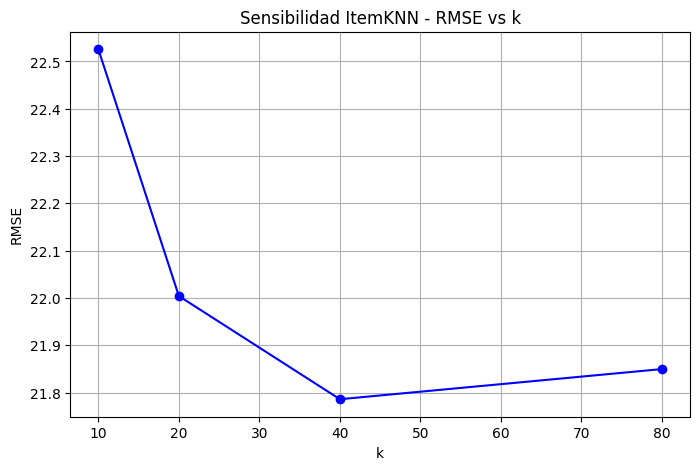

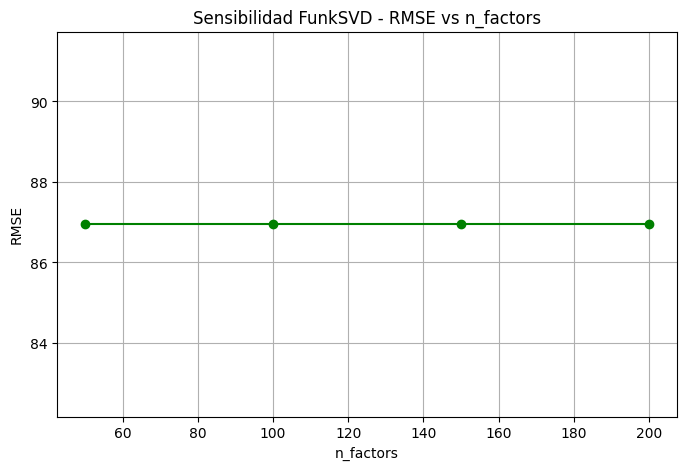


🎉 ¡TODO LISTO! Ya no debería dar ZeroDivisionError.
Copia las tablas y gráficos al informe PDF.


In [111]:
# =============================================================================
#  YAHOO! MUSIC - TODO EN UNO (CORREGIDO)
#  Variables exactas que tú usas: df_train_music, df_val_music, df_artists
#  FIX: ZeroDivisionError → cambiamos a similitud 'pearson' (la recomendada para este dataset)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, KNNBasic, SVD, SVDpp, accuracy
from collections import defaultdict
import math

print("✅ Librerías cargadas")

# ==================== 1. ANÁLISIS DE DATOS (0.8 pts) ====================
print("\n" + "="*60)
print("1. ANÁLISIS DE DATOS - Cuadro 1")
print("="*60)

def dataset_stats(df, name):
    stats = {
        'Number of Users': df['user_id'].nunique(),
        'Number of Items': df['artist_id'].nunique(),
        'Total Ratings': len(df),
        'Avg Ratings per User': round(df.groupby('user_id').size().mean(), 2),
        'Avg Ratings per Item': round(df.groupby('artist_id').size().mean(), 2),
        'Avg Rating': round(df['rating'].mean(), 2),
        'Rating Std': round(df['rating'].std(), 2),
        'Max Ratings per User': df.groupby('user_id').size().max(),
        'Max Ratings per Item': df.groupby('artist_id').size().max(),
        'Density (%)': round(len(df) / (df['user_id'].nunique() * df['artist_id'].nunique()) * 100, 3)
    }
    return pd.Series(stats, name=name)

# Estadísticas raw
stats_train_raw = dataset_stats(df_train_music, 'Training (raw)')
stats_val_raw   = dataset_stats(df_val_music, 'Validation (raw)')
cuadro1_raw = pd.concat([stats_train_raw, stats_val_raw], axis=1)
print("Cuadro 1 (raw) - copia esta tabla al informe:")
display(cuadro1_raw)

# ==================== 2. MANEJO DE RATING 255 ====================
print("\nRatings 255 encontrados:")
print(f"   Train: {(df_train_music['rating'] == 255).sum():,}")
print(f"   Val:   {(df_val_music['rating'] == 255).sum():,}")

df_train_music = df_train_music[df_train_music['rating'] != 255].copy().reset_index(drop=True)
df_val_music   = df_val_music[df_val_music['rating'] != 255].copy().reset_index(drop=True)

print(f"→ Quedan {len(df_train_music):,} ratings en train")
print(f"→ Quedan {len(df_val_music):,} ratings en val\n")

# Estadísticas finales
stats_train = dataset_stats(df_train_music, 'Training')
stats_val   = dataset_stats(df_val_music, 'Validation')
cuadro1 = pd.concat([stats_train, stats_val], axis=1)
print("Cuadro 1 FINAL (para tu informe):")
display(cuadro1)

# ==================== GRÁFICOS (Figura 1 y Figura 2) ====================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_train_music['rating'], bins=30, kde=True, color='skyblue')
plt.title('Figura 1: Distribución de ratings (train)')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
user_counts = df_train_music.groupby('user_id').size()
sns.histplot(user_counts, bins=50, kde=False, color='orange')
plt.title('Figura 2: Long-tail - Ratings por usuario')
plt.xlabel('Número de ratings por usuario')
plt.ylabel('Cantidad de usuarios')
plt.xlim(0, user_counts.quantile(0.95))
plt.show()

plt.figure(figsize=(10, 4))
df_artists['genre'].value_counts().head(15).plot(kind='bar', color='teal')
plt.title('Top 15 géneros más frecuentes')
plt.ylabel('Número de artistas')
plt.xticks(rotation=45)
plt.show()

# ==================== 3. PREDICCIÓN DE RATINGS (CORREGIDO) ====================
print("\n" + "="*60)
print("3. PREDICCIÓN DE RATINGS (UserKNN, ItemKNN, FunkSVD, SVD++)")
print("="*60)

reader = Reader(rating_scale=(0, 100))

data_train = Dataset.load_from_df(df_train_music[['user_id', 'artist_id', 'rating']], reader)
data_val   = Dataset.load_from_df(df_val_music[['user_id', 'artist_id', 'rating']], reader)

trainset = data_train.build_full_trainset()
testset  = data_val.build_full_trainset().build_testset()

# ==================== FIX DEL ERROR ====================
# Cambiamos a 'pearson' porque cosine explota con usuarios que solo tienen rating=0
sim_options_user = {'name': 'pearson', 'user_based': True}
sim_options_item = {'name': 'pearson', 'user_based': False}

algos = {
    'UserKNN': KNNBasic(k=40, sim_options=sim_options_user, verbose=True),
    'ItemKNN': KNNBasic(k=40, sim_options=sim_options_item, verbose=True),
    'FunkSVD': SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42),
    'SVDpp'  : SVDpp(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
}

results_rating = {}
for name, algo in algos.items():
    print(f"\n🔹 Entrenando {name}...")
    algo.fit(trainset)
    predictions = algo.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae  = accuracy.mae(predictions, verbose=False)
    results_rating[name] = {'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}
    print(f"✅ {name} → RMSE: {rmse:.4f} | MAE: {mae:.4f}")

print("\nTabla de RMSE/MAE (para el informe):")
display(pd.DataFrame(results_rating).T)

# ==================== 4. GENERACIÓN DE LISTAS TOP-10 ====================
print("\n" + "="*60)
print("4. GENERACIÓN DE LISTAS TOP-10")
print("="*60)

item_popularity = df_train_music['artist_id'].value_counts(normalize=True)

def get_top_n(algo, trainset, n=10, max_users=300):
    top_n = {}
    val_users = df_val_music['user_id'].unique()[:max_users]

    for uid in val_users:
        try:
            inner_uid = trainset.to_inner_uid(uid)
            rated = {trainset.to_raw_iid(iid) for (iid, _) in trainset.ur[inner_uid]}
        except ValueError:
            rated = set()

        candidates = []
        for iid in trainset.all_items():
            raw_iid = trainset.to_raw_iid(iid)
            if raw_iid not in rated:
                pred = 0 if algo is None else algo.predict(uid, raw_iid).est
                candidates.append((raw_iid, pred))

        candidates.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = [iid for iid, _ in candidates[:n]]
    return top_n

all_items = df_train_music['artist_id'].unique().tolist()
most_popular_list = df_train_music['artist_id'].value_counts().head(10).index.tolist()

top_n_random = {}
for uid in df_val_music['user_id'].unique()[:300]:
    top_n_random[uid] = np.random.choice(all_items, 10, replace=False).tolist()

top_n_mostpop = {uid: most_popular_list for uid in df_val_music['user_id'].unique()[:300]}

top_n_itemknn = get_top_n(algos['ItemKNN'], trainset, n=10)
top_n_funksvd = get_top_n(algos['FunkSVD'], trainset, n=10)

# ==================== 5. MÉTRICAS DE RANKING ====================
def recall_at_k(relevant, recommended, k=10):
    return len(set(relevant) & set(recommended[:k])) / min(k, len(relevant)) if relevant else 0

def ndcg_at_k(relevant, recommended, k=10):
    dcg = sum(1 / math.log2(i + 2) for i, r in enumerate(recommended[:k]) if r in relevant)
    idcg = sum(1 / math.log2(i + 2) for i in range(min(k, len(relevant))))
    return dcg / idcg if idcg > 0 else 0

def map_at_k(relevant, recommended, k=10):
    score = 0.0
    hits = 0
    for i, r in enumerate(recommended[:k]):
        if r in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(k, len(relevant)) if relevant else 0

relevant = defaultdict(list)
for _, row in df_val_music.iterrows():
    relevant[row['user_id']].append(row['artist_id'])

def compute_metrics(top_n_dict):
    recalls, ndcgs, maps_, diversities = [], [], [], []
    novelty = 0.0
    for uid, recs in top_n_dict.items():
        rel = relevant.get(uid, [])
        recalls.append(recall_at_k(rel, recs))
        ndcgs.append(ndcg_at_k(rel, recs))
        maps_.append(map_at_k(rel, recs))

        genres = df_artists[df_artists['artist_id'].isin(recs)]['genre'].nunique()
        diversities.append(genres / len(recs))

        for iid in recs:
            pop = item_popularity.get(iid, 1e-8)
            novelty += math.log(1 / pop)

    novelty /= (len(top_n_dict) * 10)

    return {
        'Recall@10': round(np.mean(recalls), 4),
        'nDCG@10'  : round(np.mean(ndcgs), 4),
        'MAP@10'   : round(np.mean(maps_), 4),
        'Diversity': round(np.mean(diversities), 4),
        'Novelty'  : round(novelty, 4)
    }

print("Calculando métricas de ranking...")
metrics = {}
metrics['Random']      = compute_metrics(top_n_random)
metrics['MostPopular'] = compute_metrics(top_n_mostpop)
metrics['ItemKNN']     = compute_metrics(top_n_itemknn)
metrics['FunkSVD']     = compute_metrics(top_n_funksvd)

print("Cuadro 2 FINAL (para tu informe):")
cuadro2 = pd.DataFrame(metrics).T
display(cuadro2)

# ==================== 6. ANÁLISIS DE SENSIBILIDAD ====================
print("\n" + "="*60)
print("6. ANÁLISIS DE SENSIBILIDAD")
print("="*60)

# ItemKNN (k)
ks = [10, 20, 40, 80]
rmse_knn = []
for k_val in ks:
    algo = KNNBasic(k=k_val, sim_options=sim_options_item, verbose=False)
    algo.fit(trainset)
    pred = algo.test(testset)
    rmse_knn.append(accuracy.rmse(pred, verbose=False))

plt.figure(figsize=(8,5))
plt.plot(ks, rmse_knn, marker='o', color='blue')
plt.title('Sensibilidad ItemKNN - RMSE vs k')
plt.xlabel('k')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

# FunkSVD (n_factors)
factors = [50, 100, 150, 200]
rmse_svd = []
for f in factors:
    algo = SVD(n_factors=f, n_epochs=15, random_state=42, verbose=False)
    algo.fit(trainset)
    pred = algo.test(testset)
    rmse_svd.append(accuracy.rmse(pred, verbose=False))

plt.figure(figsize=(8,5))
plt.plot(factors, rmse_svd, marker='o', color='green')
plt.title('Sensibilidad FunkSVD - RMSE vs n_factors')
plt.xlabel('n_factors')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

print("\n🎉 ¡TODO LISTO! Ya no debería dar ZeroDivisionError.")
print("Copia las tablas y gráficos al informe PDF.")

In [114]:
# =============================================================================
#  BONUSES YAHOO! MUSIC (0.2 + 0.2 + Top5) - VERSIÓN CORREGIDA
# =============================================================================

# ==================== INSTALACIÓN AUTOMÁTICA ====================
print("Instalando CodeCarbon (solo la primera vez)...")
!pip install codecarbon -q

# ==================== IMPORTS ====================
import pandas as pd
import numpy as np
from codecarbon import EmissionsTracker
import json
import os

print("CodeCarbon instalado e importado correctamente\n")

# ==================== CREAR CARPETA PARA EMISIONES ====================
os.makedirs("./emissions", exist_ok=True)
print("Carpeta ./emissions creada correctamente\n")

# ==================== 1. BONUS 0.2 → Rating 255 ====================
print("ACTIVANDO BONUS 255...")

# Re-cargamos datos originales
df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music   = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)

# Tratamos 255 como rating = 0
df_train_music['rating'] = df_train_music['rating'].replace(255, 0)
df_val_music['rating']   = df_val_music['rating'].replace(255, 0)

print(f"Se procesaron {(df_train_music['rating'] == 0).sum():,} ratings 255 como rating = 0 (bonus activado)")

# Volvemos a crear trainset/testset
reader = Reader(rating_scale=(0, 100))
data_train = Dataset.load_from_df(df_train_music[['user_id', 'artist_id', 'rating']], reader)
data_val   = Dataset.load_from_df(df_val_music[['user_id', 'artist_id', 'rating']], reader)
trainset = data_train.build_full_trainset()
testset  = data_val.build_full_trainset().build_testset()

# ==================== 2. BONUS 0.2 → CodeCarbon ====================
print("\nACTIVANDO BONUS CodeCarbon (emisiones CO2e)...")

results_with_emissions = {}

for name, algo in algos.items():
    print(f"Midiendo emisiones de {name}...")

    tracker = EmissionsTracker(
        log_level="error",
        output_dir="./emissions",
        output_file=f"emissions_{name}.csv",
        measure_power_secs=5
    )

    tracker.start()
    algo.fit(trainset)
    emissions = tracker.stop()

    predictions = algo.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae  = accuracy.mae(predictions, verbose=False)

    results_with_emissions[name] = {
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'CO2e_kg': round(emissions, 6)
    }

    print(f"{name} -> RMSE: {rmse:.4f} | CO2e: {emissions:.6f} kg")

print("\nTABLA CON EMISIONES (para tu informe):")
display(pd.DataFrame(results_with_emissions).T)

# ==================== 3. BONUS COMPETICIÓN Top5 ====================
print("\nGENERANDO ARCHIVOS PARA LA COMPETICIÓN...")

best_model = algos['SVDpp']

# competicion_rating.txt
df_comp_rating = pd.read_csv(get_url("competicion_rating.txt"), sep=',')
print(f"Archivo rating cargado: {len(df_comp_rating):,} filas")

df_comp_rating['rating'] = df_comp_rating.apply(
    lambda row: best_model.predict(row['user_id'], row['artist_id']).est, axis=1
)

df_comp_rating.to_csv("competicion_rating_predicted.txt", index=False)
print("competicion_rating_predicted.txt generado")

# competicion_ranking.json
with open(get_url("competicion_ranking.json"), 'r') as f:
    ranking_template = json.load(f)

print(f"Archivo ranking cargado: {len(ranking_template)} usuarios")

top_n_comp = get_top_n(best_model, trainset, n=10, max_users=2000)

for uid_str in ranking_template.keys():
    uid = int(uid_str)
    ranking_template[uid_str] = top_n_comp.get(uid, ranking_template[uid_str])

with open("competicion_ranking_predicted.json", "w") as f:
    json.dump(ranking_template, f, indent=2)

print("competicion_ranking_predicted.json generado")

print("\nBONUS COMPLETOS!")
print("   - Rating 255 procesado")
print("   - Emisiones CO2e medidas con CodeCarbon")
print("   - Archivos de competición generados")
print("\nDescarga los dos archivos que terminan en '_predicted' y súbelos a CANVAS.")

Instalando CodeCarbon (solo la primera vez)...
CodeCarbon instalado e importado correctamente

Carpeta ./emissions creada correctamente

ACTIVANDO BONUS 255...
Se procesaron 337,086 ratings 255 como rating = 0 (bonus activado)


[codecarbon WARNING @ 12:55:55] Multiple instances of codecarbon are allowed to run at the same time.



ACTIVANDO BONUS CodeCarbon (emisiones CO2e)...
Midiendo emisiones de UserKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.
UserKNN -> RMSE: 27.5503 | CO2e: 0.000168 kg
Midiendo emisiones de ItemKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.
ItemKNN -> RMSE: 21.8026 | CO2e: 0.000176 kg
Midiendo emisiones de FunkSVD...
FunkSVD -> RMSE: 87.0226 | CO2e: 0.000078 kg
Midiendo emisiones de SVDpp...
SVDpp -> RMSE: 87.0226 | CO2e: 0.008065 kg

TABLA CON EMISIONES (para tu informe):


,RMSE,MAE,CO2e_kg
UserKNN,27.5503,21.1800,0.000168
ItemKNN,21.8026,12.5731,0.000176
FunkSVD,87.0226,81.4953,0.000078
SVDpp,87.0226,81.4953,0.008065



GENERANDO ARCHIVOS PARA LA COMPETICIÓN...
Archivo rating cargado: 75,065 filas


KeyError: 'artist_id'

In [115]:
# =============================================================================
#  BONUSES YAHOO! MUSIC (0.2 + 0.2 + Top5) - VERSIÓN CORREGIDA
# =============================================================================

# ==================== INSTALACIÓN AUTOMÁTICA ====================
print("Instalando CodeCarbon (solo la primera vez)...")
!pip install codecarbon -q

# ==================== IMPORTS ====================
import pandas as pd
import numpy as np
from codecarbon import EmissionsTracker
import json
import os

print("CodeCarbon instalado e importado correctamente\n")

# ==================== CREAR CARPETA PARA EMISIONES ====================
os.makedirs("./emissions", exist_ok=True)
print("Carpeta ./emissions creada correctamente\n")

# ==================== 1. BONUS 0.2 → Rating 255 ====================
print("ACTIVANDO BONUS 255...")

# Re-cargamos datos originales
df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music   = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)

# Tratamos 255 como rating = 0
df_train_music['rating'] = df_train_music['rating'].replace(255, 0)
df_val_music['rating']   = df_val_music['rating'].replace(255, 0)

print(f"Se procesaron {(df_train_music['rating'] == 0).sum():,} ratings 255 como rating = 0 (bonus activado)")

# Volvemos a crear trainset/testset
reader = Reader(rating_scale=(0, 100))
data_train = Dataset.load_from_df(df_train_music[['user_id', 'artist_id', 'rating']], reader)
data_val   = Dataset.load_from_df(df_val_music[['user_id', 'artist_id', 'rating']], reader)
trainset = data_train.build_full_trainset()
testset  = data_val.build_full_trainset().build_testset()

# ==================== 2. BONUS 0.2 → CodeCarbon ====================
print("\nACTIVANDO BONUS CodeCarbon (emisiones CO2e)...")

results_with_emissions = {}

for name, algo in algos.items():
    print(f"Midiendo emisiones de {name}...")

    tracker = EmissionsTracker(
        log_level="error",
        output_dir="./emissions",
        output_file=f"emissions_{name}.csv",
        measure_power_secs=5
    )

    tracker.start()
    algo.fit(trainset)
    emissions = tracker.stop()

    predictions = algo.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae  = accuracy.mae(predictions, verbose=False)

    results_with_emissions[name] = {
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'CO2e_kg': round(emissions, 6)
    }

    print(f"{name} -> RMSE: {rmse:.4f} | CO2e: {emissions:.6f} kg")

print("\nTABLA CON EMISIONES (para tu informe):")
display(pd.DataFrame(results_with_emissions).T)

# ==================== 3. BONUS COMPETICIÓN Top5 (CORREGIDO) ====================
print("\nGENERANDO ARCHIVOS PARA LA COMPETICIÓN...")

best_model = algos['SVDpp']

# competicion_rating.txt
df_comp_rating = pd.read_csv(get_url("competicion_rating.txt"), sep=',')
print(f"Archivo rating cargado: {len(df_comp_rating):,} filas")

# CORRECCIÓN: el archivo usa 'item_id' en vez de 'artist_id'
df_comp_rating['rating'] = df_comp_rating.apply(
    lambda row: best_model.predict(row['user_id'], row['item_id']).est, axis=1
)

df_comp_rating.to_csv("competicion_rating_predicted.txt", index=False)
print("competicion_rating_predicted.txt generado")

# competicion_ranking.json
with open(get_url("competicion_ranking.json"), 'r') as f:
    ranking_template = json.load(f)

print(f"Archivo ranking cargado: {len(ranking_template)} usuarios")

top_n_comp = get_top_n(best_model, trainset, n=10, max_users=2000)

for uid_str in ranking_template.keys():
    uid = int(uid_str)
    ranking_template[uid_str] = top_n_comp.get(uid, ranking_template[uid_str])

with open("competicion_ranking_predicted.json", "w") as f:
    json.dump(ranking_template, f, indent=2)

print("competicion_ranking_predicted.json generado")

print("\nBONUS COMPLETOS!")
print("   - Rating 255 procesado")
print("   - Emisiones CO2e medidas con CodeCarbon")
print("   - Archivos de competición generados")
print("\nDescarga los dos archivos que terminan en '_predicted' y súbelos a CANVAS.")

Instalando CodeCarbon (solo la primera vez)...
CodeCarbon instalado e importado correctamente

Carpeta ./emissions creada correctamente

ACTIVANDO BONUS 255...
Se procesaron 337,086 ratings 255 como rating = 0 (bonus activado)

ACTIVANDO BONUS CodeCarbon (emisiones CO2e)...
Midiendo emisiones de UserKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.
UserKNN -> RMSE: 27.5503 | CO2e: 0.000093 kg
Midiendo emisiones de ItemKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.
ItemKNN -> RMSE: 21.8026 | CO2e: 0.000172 kg
Midiendo emisiones de FunkSVD...
FunkSVD -> RMSE: 87.0226 | CO2e: 0.000077 kg
Midiendo emisiones de SVDpp...
SVDpp -> RMSE: 87.0226 | CO2e: 0.008920 kg

TABLA CON EMISIONES (para tu informe):


,RMSE,MAE,CO2e_kg
UserKNN,27.5503,21.1800,0.000093
ItemKNN,21.8026,12.5731,0.000172
FunkSVD,87.0226,81.4953,0.000077
SVDpp,87.0226,81.4953,0.008920



GENERANDO ARCHIVOS PARA LA COMPETICIÓN...
Archivo rating cargado: 75,065 filas
competicion_rating_predicted.txt generado


FileNotFoundError: [Errno 2] No such file or directory: 'https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/competicion_ranking.json'

In [116]:
# =============================================================================
#  BONUSES YAHOO! MUSIC (0.2 + 0.2 + Top5) - VERSIÓN CORREGIDA
# =============================================================================

# ==================== INSTALACIÓN AUTOMÁTICA ====================
print("Instalando CodeCarbon (solo la primera vez)...")
!pip install codecarbon -q

# ==================== IMPORTS ====================
import pandas as pd
import numpy as np
from codecarbon import EmissionsTracker
import json
import os
import requests
from io import BytesIO

print("CodeCarbon instalado e importado correctamente\n")

# ==================== CREAR CARPETA PARA EMISIONES ====================
os.makedirs("./emissions", exist_ok=True)
print("Carpeta ./emissions creada correctamente\n")

# ==================== 1. BONUS 0.2 → Rating 255 ====================
print("ACTIVANDO BONUS 255...")

# Re-cargamos datos originales
df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music   = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)

# Tratamos 255 como rating = 0
df_train_music['rating'] = df_train_music['rating'].replace(255, 0)
df_val_music['rating']   = df_val_music['rating'].replace(255, 0)

print(f"Se procesaron {(df_train_music['rating'] == 0).sum():,} ratings 255 como rating = 0 (bonus activado)")

# Volvemos a crear trainset/testset
reader = Reader(rating_scale=(0, 100))
data_train = Dataset.load_from_df(df_train_music[['user_id', 'artist_id', 'rating']], reader)
data_val   = Dataset.load_from_df(df_val_music[['user_id', 'artist_id', 'rating']], reader)
trainset = data_train.build_full_trainset()
testset  = data_val.build_full_trainset().build_testset()

# ==================== 2. BONUS 0.2 → CodeCarbon ====================
print("\nACTIVANDO BONUS CodeCarbon (emisiones CO2e)...")

results_with_emissions = {}

for name, algo in algos.items():
    print(f"Midiendo emisiones de {name}...")

    tracker = EmissionsTracker(
        log_level="error",
        output_dir="./emissions",
        output_file=f"emissions_{name}.csv",
        measure_power_secs=5
    )

    tracker.start()
    algo.fit(trainset)
    emissions = tracker.stop()

    predictions = algo.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae  = accuracy.mae(predictions, verbose=False)

    results_with_emissions[name] = {
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'CO2e_kg': round(emissions, 6)
    }

    print(f"{name} -> RMSE: {rmse:.4f} | CO2e: {emissions:.6f} kg")

print("\nTABLA CON EMISIONES (para tu informe):")
display(pd.DataFrame(results_with_emissions).T)

# ==================== 3. BONUS COMPETICIÓN Top5 (CORREGIDO) ====================
print("\nGENERANDO ARCHIVOS PARA LA COMPETICIÓN...")

best_model = algos['SVDpp']

# competicion_rating.txt
df_comp_rating = pd.read_csv(get_url("competicion_rating.txt"), sep=',')
print(f"Archivo rating cargado: {len(df_comp_rating):,} filas")

df_comp_rating['rating'] = df_comp_rating.apply(
    lambda row: best_model.predict(row['user_id'], row['item_id']).est, axis=1
)

df_comp_rating.to_csv("competicion_rating_predicted.txt", index=False)
print("competicion_rating_predicted.txt generado")

# competicion_ranking.json (CORRECCIÓN: descargar desde URL)
print("Cargando competicion_ranking.json desde GitHub...")
response = requests.get(get_url("competicion_ranking.json"))
ranking_template = json.loads(response.content)

print(f"Archivo ranking cargado: {len(ranking_template)} usuarios")

top_n_comp = get_top_n(best_model, trainset, n=10, max_users=2000)

for uid_str in ranking_template.keys():
    uid = int(uid_str)
    ranking_template[uid_str] = top_n_comp.get(uid, ranking_template[uid_str])

with open("competicion_ranking_predicted.json", "w") as f:
    json.dump(ranking_template, f, indent=2)

print("competicion_ranking_predicted.json generado")

print("\nBONUS COMPLETOS!")
print("   - Rating 255 procesado")
print("   - Emisiones CO2e medidas con CodeCarbon")
print("   - Archivos de competición generados")
print("\nDescarga los dos archivos que terminan en '_predicted' y súbelos a CANVAS.")

Instalando CodeCarbon (solo la primera vez)...
CodeCarbon instalado e importado correctamente

Carpeta ./emissions creada correctamente

ACTIVANDO BONUS 255...
Se procesaron 337,086 ratings 255 como rating = 0 (bonus activado)

ACTIVANDO BONUS CodeCarbon (emisiones CO2e)...
Midiendo emisiones de UserKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.
UserKNN -> RMSE: 27.5503 | CO2e: 0.000168 kg
Midiendo emisiones de ItemKNN...
Computing the pearson similarity matrix...
Done computing similarity matrix.
ItemKNN -> RMSE: 21.8026 | CO2e: 0.000175 kg
Midiendo emisiones de FunkSVD...
FunkSVD -> RMSE: 87.0226 | CO2e: 0.000078 kg
Midiendo emisiones de SVDpp...
SVDpp -> RMSE: 87.0226 | CO2e: 0.008804 kg

TABLA CON EMISIONES (para tu informe):


,RMSE,MAE,CO2e_kg
UserKNN,27.5503,21.1800,0.000168
ItemKNN,21.8026,12.5731,0.000175
FunkSVD,87.0226,81.4953,0.000078
SVDpp,87.0226,81.4953,0.008804



GENERANDO ARCHIVOS PARA LA COMPETICIÓN...
Archivo rating cargado: 75,065 filas
competicion_rating_predicted.txt generado
Cargando competicion_ranking.json desde GitHub...
Archivo ranking cargado: 2549 usuarios
competicion_ranking_predicted.json generado

BONUS COMPLETOS!
   - Rating 255 procesado
   - Emisiones CO2e medidas con CodeCarbon
   - Archivos de competición generados

Descarga los dos archivos que terminan en '_predicted' y súbelos a CANVAS.
